In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import glob
from scipy.stats import linregress
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


# select demand for victoria and sort in order of date
#demand = glob.glob("/Users/Coder/Desktop/ADS1002-project/data/processed/VIC_clean.csv")
demand = glob.glob("/Users/Coder/Desktop/ADS1002-project/data/processed/master_data.csv")

demand.sort()

df_list = [pd.read_csv(f) for f in demand]
if df_list:
    print("CSV files loaded")
else:
    print("No CSV files were loaded.")


df = pd.concat(df_list, ignore_index=True)

# Parse datetime column
df['Datetime'] = pd.to_datetime(df['Datetime'], format="%Y/%m/%d %H:%M")

# Extract hour of the day
df['Hour'] = df['Datetime'].dt.hour

# Extract year column
df['Year'] = df['Datetime'].dt.year

df['Day'] = df['Datetime'].dt.day_name()


# Data separation as X and Y
x = pd.get_dummies(df['Day'])  # One-hot encode day of week
y = df['Total Demand']

'''
# Data splitting
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2, random_state=100)

# Model building with Random Forest
rf = RandomForestRegressor()
rf.fit(X_train, Y_train)

# Predictions
y_rf_train_pred = rf.predict(X_train)
y_rf_test_pred = rf.predict(X_test)

# Model performance
rf_train_mse = mean_squared_error(Y_train, y_rf_train_pred)
rf_train_r2 = r2_score(Y_train, y_rf_train_pred)
rf_test_mse = mean_squared_error(Y_test, y_rf_test_pred)
rf_test_r2 = r2_score(Y_test, y_rf_test_pred)

# Build DataFrame for plotting
plot_df = pd.DataFrame({
    "Day": X_test.idxmax(axis=1),  # Get the day name from one-hot encoded columns
    "Actual_Demand": Y_test.values,
    "Predicted_Demand": y_rf_test_pred
})

# Ensure 'Day' is categorical
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plot_df["Day"] = pd.Categorical(plot_df["Day"], categories=day_order, ordered=True)

# Debug: Print DataFrame to verify
print("plot_df head:")
print(plot_df.head())
print("plot_df shape:", plot_df.shape)
print("Unique days in plot_df:", plot_df["Day"].unique())

# Create the plot
plt.figure(figsize=(12, 6))

# Scatter plot of actual values
sns.scatterplot(
    data=plot_df,
    x="Day",
    y="Actual_Demand",
    palette="tab10",
    s=60,
    alpha=0.8,
    label="Actual"
)

# Scatter plot of predicted values
plt.scatter(
    x=plot_df["Day"],
    y=plot_df["Predicted_Demand"],
    color="red",
    s=40,
    alpha=0.5,
    label="Predicted"
)

# Title & labels
plt.title("Random Forest: Actual vs Predicted Demand by Day", fontsize=14)
plt.xlabel("Day")
plt.ylabel("Demand")
plt.xticks(rotation=45)

# Move legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0)

plt.tight_layout()
plt.show()
'''

CSV files loaded


'\n# Data splitting\nX_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2, random_state=100)\n\n# Model building with Random Forest\nrf = RandomForestRegressor()\nrf.fit(X_train, Y_train)\n\n# Predictions\ny_rf_train_pred = rf.predict(X_train)\ny_rf_test_pred = rf.predict(X_test)\n\n# Model performance\nrf_train_mse = mean_squared_error(Y_train, y_rf_train_pred)\nrf_train_r2 = r2_score(Y_train, y_rf_train_pred)\nrf_test_mse = mean_squared_error(Y_test, y_rf_test_pred)\nrf_test_r2 = r2_score(Y_test, y_rf_test_pred)\n\n# Build DataFrame for plotting\nplot_df = pd.DataFrame({\n    "Day": X_test.idxmax(axis=1),  # Get the day name from one-hot encoded columns\n    "Actual_Demand": Y_test.values,\n    "Predicted_Demand": y_rf_test_pred\n})\n\n# Ensure \'Day\' is categorical\nday_order = [\'Monday\', \'Tuesday\', \'Wednesday\', \'Thursday\', \'Friday\', \'Saturday\', \'Sunday\']\nplot_df["Day"] = pd.Categorical(plot_df["Day"], categories=day_order, ordered=True)\n\n# Debug

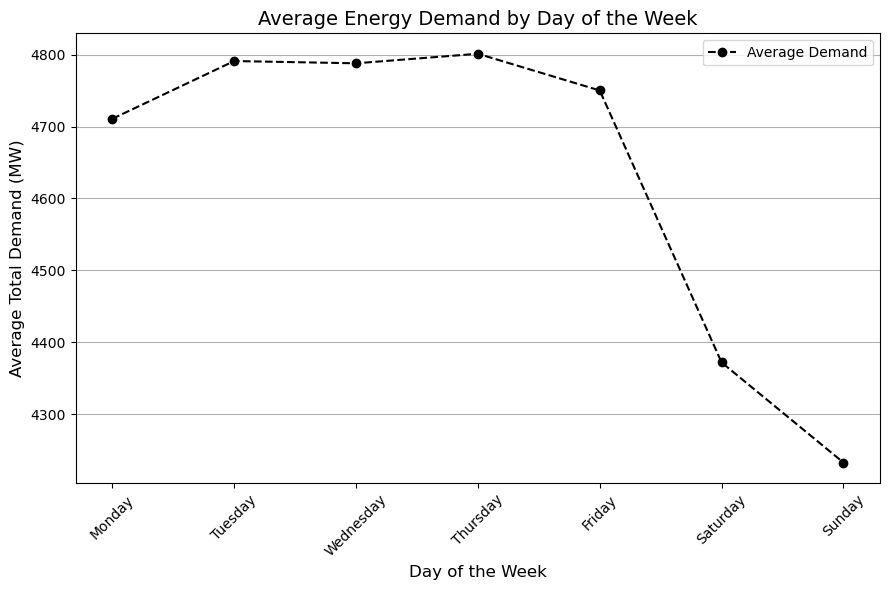

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is already loaded with 'Day' and 'Total Demand' columns from your previous code

# Define the correct order of days starting from Monday
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Calculate the average energy demand per day
avg_demand_by_day = df.groupby('Day')['Total Demand'].mean().reset_index()

# Reorder the days to start with Monday
avg_demand_by_day['Day'] = pd.Categorical(avg_demand_by_day['Day'], categories=day_order, ordered=True)
avg_demand_by_day = avg_demand_by_day.sort_values('Day')

# Create a line plot with dots
plt.figure(figsize=(9, 6))
plt.plot(avg_demand_by_day['Day'], avg_demand_by_day['Total Demand'], marker='o', linestyle='--', color='black', label='Average Demand')
plt.title('Average Energy Demand by Day of the Week', fontsize=14)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Average Total Demand (MW)', fontsize=12)
plt.grid(True, axis='y')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.legend()
plt.tight_layout()

# Show the plot
plt.show()